## Question 1: Piecewise Linear Intensity Transformation

### Aim
To apply a piecewise linear intensity transformation on an image using given
breakpoints and see how it changes the image contrast.

### Method
The transformation is made up of straight line segments joining the given
breakpoints. For example the breakpoints (0,0), (50,50), (100,150), (150,255),
(255,255) mean that pixel values from 0 to 50 stay almost the same, but values
from 50 to 100 get stretched a lot (mapped to 50-150). This makes the mid tones
brighter and increases contrast in that range.

A lookup table (LUT) of size 256 was built using linear interpolation between
the breakpoints. This table was then applied to every pixel in the image using
cv2.LUT, which is faster than looping over each pixel.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs = breakpoints[:, 0]
    ys = breakpoints[:, 1]
    x_full = np.arange(256)
    lut = np.interp(x_full, xs, ys).astype(np.uint8)
    transformed = cv2.LUT(im, lut)
    return transformed, lut

im = cv2.imread('/content/drive/MyDrive/EN3160/data/emma.jpeg', cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]

transformed, lut = intensity_transform(im, breakpoints)

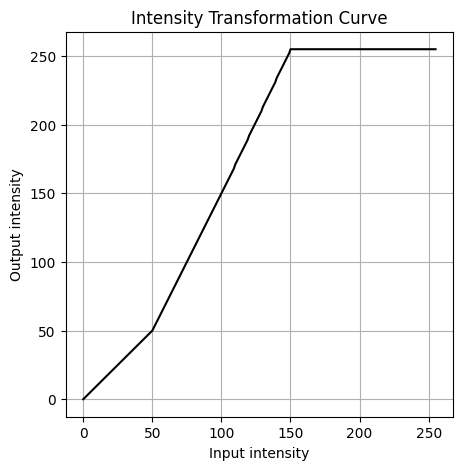

In [13]:
plt.figure(figsize=(5,5))
plt.plot(np.arange(256), lut, 'k')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity Transformation Curve')
plt.grid(True)
plt.show()

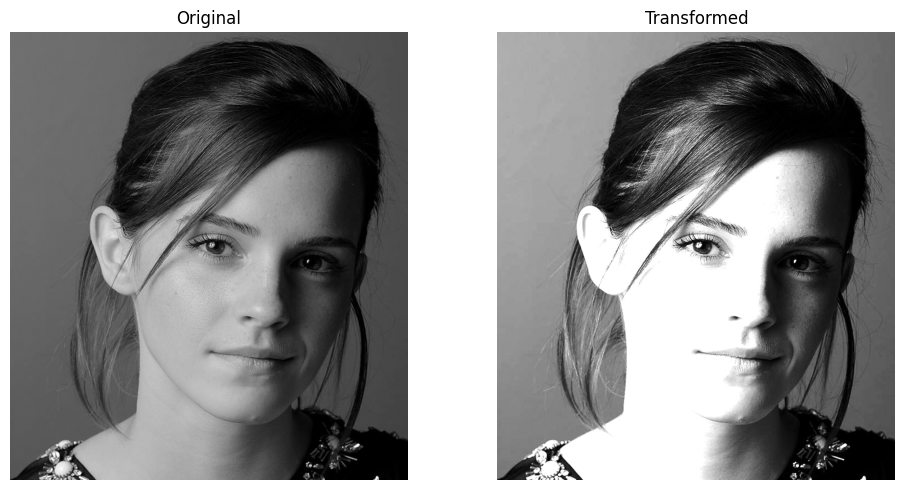

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray')
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Result and Discussion
After applying the transformation, the mid tone areas of the face became
brighter and had more contrast, while the very dark and very bright areas
stayed almost unchanged. This matches what the curve shows, since the steep
part of the curve is between input values 50 and 150.

I also tried different breakpoints to check what looks best. Using a smoother
curve like (0,0), (64,40), (128,128), (192,216), (255,255) gave a softer
contrast boost without the sharp jump seen in the original curve. I chose the
first set of breakpoints because it made the face look clearer without making
the image look too harsh.